In [1]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
import tensorflow_datasets as tfds

import matplotlib.pyplot as plt
%matplotlib inline  

import importlib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pprint

import keras_tuner

tfk = tf.keras
tfkl = tfk.layers

In [2]:
BATCH_SIZE = 512

(ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

ds_train = ds_train.cache()
ds_train = ds_train.shuffle(ds_info.splits['train'].num_examples)
ds_train = ds_train.batch(BATCH_SIZE)
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)

ds_test = ds_test.batch(BATCH_SIZE)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

In [3]:
def build_model(hp):

    module = importlib.import_module('arnold.layers.polynomial.orthogonal')

    model = tfk.Sequential()
    model.add(tfkl.Reshape(target_shape=(784, )))
    model.add(tfkl.Rescaling(scale=1./127.5, offset=-1))

    from arnold.layers.polynomial.orthogonal import Pollaczek
    available_layers =  [
        'AlSalamCarlitz1st',
        'AlSalamCarlitz2nd',
        'AskeyWilson',
        'BannaiIto',
        'Bessel', 
        'Charlier',
        'Chebyshev1st', 
        'Chebyshev2nd', 
        'Chebyshev3rd', 
        'Chebyshev4th', 
        'Gegenbauer', 
        'Hermite', 
        'Jacobi',
        'GeneralizedLaguerre',
        'Legendre',
        'AssociatedMeixnerPollaczek',
        'Pollaczek'
    ]

    # first KAN layer
    model.add(
        getattr(module, hp.Choice('layer_type_0', available_layers))(
            input_dim=784,
            output_dim=hp.Int("output_dim_0", min_value=32, max_value=512, step=32),
            degree=hp.Int("degree_0", min_value=1, max_value=8, step=1),
        )
    )

    # Tune the number of layers.
    for i in range(hp.Int("num_layers", 1, 7)):

        model.add(tfkl.LayerNormalization())

        model.add(
           getattr(module, hp.Choice('layer_type_{}'.format(i+1), ['Bessel', 'Chebyshev1st', 'Gegenbauer', 'Hermite', 'Jacobi']))(
                input_dim=hp.get('output_dim_{}'.format(i)),
                output_dim=hp.Int("output_dim_{}".format(i+1), min_value=32, max_value=512, step=32),
                degree=hp.Int("degree_{}".format(i+1), min_value=1, max_value=8, step=1),
            )
        )

    # last KAN layer
    model.add(tfkl.LayerNormalization())
    model.add(
        getattr(module, hp.Choice('layer_type_{}'.format(hp.get('num_layers') + 1), ['Bessel', 'Chebyshev1st', 'Gegenbauer', 'Hermite', 'Jacobi']))(
            input_dim=hp.get('output_dim_{}'.format(hp.get('num_layers') )),
            output_dim=10,
            degree=hp.Int('degree_{}'.format(hp.get('num_layers') + 1), min_value=1, max_value=8, step=1),
        )
    )
    model.add(tfkl.Softmax())


    learning_rate = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    model.compile(
        optimizer=tfk.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    return model

In [4]:
tuner = keras_tuner.Hyperband(
    hypermodel=build_model,
    objective="val_accuracy",
    max_epochs=4,
    factor=3,
    hyperband_iterations=1,
    seed=None,
    hyperparameters=None,
    tune_new_entries=True,
    allow_new_entries=True,
    max_retries_per_trial=0,
    max_consecutive_failed_trials=3,
)

In [5]:
tuner.search_space_summary()

Search space summary
Default search space size: 10
layer_type_0 (Choice)
{'default': 'AlSalamCarlitz1st', 'conditions': [], 'values': ['AlSalamCarlitz1st', 'AlSalamCarlitz2nd', 'AskeyWilson', 'BannaiIto', 'Bessel', 'Charlier', 'Chebyshev1st', 'Chebyshev2nd', 'Chebyshev3rd', 'Chebyshev4th', 'Gegenbauer', 'Hermite', 'Jacobi', 'GeneralizedLaguerre', 'Legendre', 'AssociatedMeixnerPollaczek', 'Pollaczek'], 'ordered': False}
output_dim_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
degree_0 (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 8, 'step': 1, 'sampling': 'linear'}
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 7, 'step': 1, 'sampling': 'linear'}
layer_type_1 (Choice)
{'default': 'Bessel', 'conditions': [], 'values': ['Bessel', 'Chebyshev1st', 'Gegenbauer', 'Hermite', 'Jacobi'], 'ordered': False}
output_dim_1 (Int)
{'default': None, 'conditions': [], 'min_value'

In [6]:
tuner.search(ds_train, epochs=2, validation_data=ds_test)

Trial 9 Complete [00h 00m 00s]

Best val_accuracy So Far: 0.9509999752044678
Total elapsed time: 00h 01m 34s


In [7]:
tuner.get_best_models()[0].summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev4th (Chebyshev4th)     │ (None, 32)             │       125,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bessel (Bessel)                 │ (None, 288)            │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 288)            │           576 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev1st (Chebyshev1st)     │ (None, 10)             │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,984 (726.50 KB)

 Trainable params: 185,984 (726.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

In [9]:
model = tuner.hypermodel.build(best_hps)

In [10]:
history = model.fit(ds_train, epochs=50)

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6306 - loss: 1.3158
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9241 - loss: 0.2602
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9490 - loss: 0.1748
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9590 - loss: 0.1414
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9686 - loss: 0.1080
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9726 - loss: 0.0949
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9774 - loss: 0.0794
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9809 - loss: 0.0651
Epoch 9/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9824 - loss: 0.0618
Epoch 10/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9869 - loss: 0.0497
Epoch 11/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9847 - loss: 0.0542
Epoch 12/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 

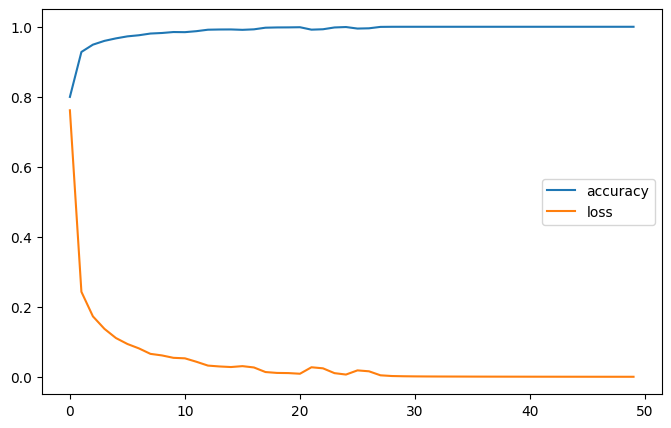

In [11]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev4th_1 (Chebyshev4th)   │ (None, 32)             │       125,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bessel_1 (Bessel)               │ (None, 288)            │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 288)            │           576 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev1st_1 (Chebyshev1st)   │ (None, 10)             │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,954 (2.13 MB)

 Trainable params: 185,984 (726.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 371,970 (1.42 MB)